
===== KỊCH BẢN 1: 1 user + Eve, mô phỏng theo d_{AE} =====
==== THÔNG SỐ HỆ THỐNG ====
Công suất truyền P_A: 1 W
Nhiễu nền N_0: 3.98e-17 W
Hệ số suy hao alpha: 3
Ngưỡng bảo mật epsilon_S: 0.5000 (bits/s/Hz)
Băng thông: 10.0 MHz
Khoảng cách d_B: 50
Khoảng cách d_E: 100.0 -> 500.0 m (step 8.2)

d_E = 100.0 m | O_S = 0.1539 | R_s = 3.1335 | eta_s = 3.1335
d_E = 108.2 m | O_S = 0.1172 | R_s = 3.5271 | eta_s = 3.5271
d_E = 116.3 m | O_S = 0.0981 | R_s = 3.7439 | eta_s = 3.7439
d_E = 124.5 m | O_S = 0.0848 | R_s = 4.0410 | eta_s = 4.0410
d_E = 132.7 m | O_S = 0.0705 | R_s = 4.2964 | eta_s = 4.2964
d_E = 140.8 m | O_S = 0.0616 | R_s = 4.5420 | eta_s = 4.5420
d_E = 149.0 m | O_S = 0.0461 | R_s = 4.7950 | eta_s = 4.7950
d_E = 157.1 m | O_S = 0.0409 | R_s = 5.0044 | eta_s = 5.0044
d_E = 165.3 m | O_S = 0.0312 | R_s = 5.2298 | eta_s = 5.2298
d_E = 173.5 m | O_S = 0.0321 | R_s = 5.4469 | eta_s = 5.4469
d_E = 181.6 m | O_S = 0.0263 | R_s = 5.5916 | eta_s = 5.5916
d_E = 189.8 m | O_S = 0.0234 | R_s

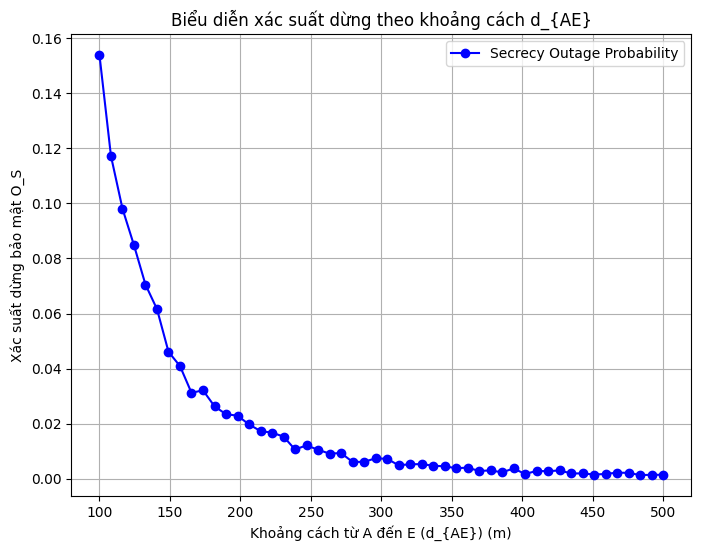

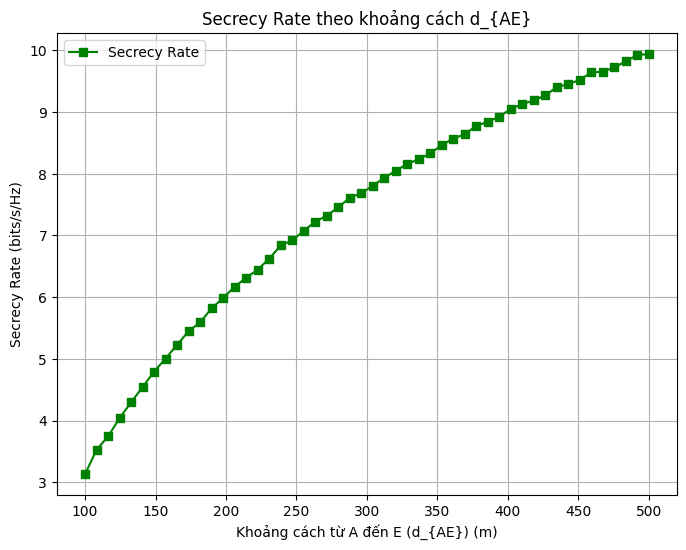

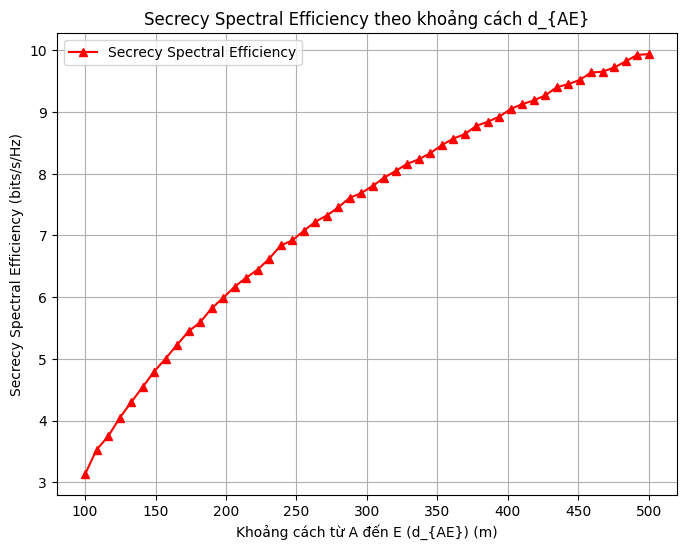


===== KỊCH BẢN 2: Multi-user NOMA, mô phỏng theo SNR =====
Phân bổ công suất: alpha1 = 0.7, alpha2 = 0.3 (tổng = 1.0)
Khoảng cách: Bob1 = 50m, Bob2 = 100m, Eve = 200m
SNR = -10 dB | C_B1 = 0.91 Mbps | C_B2 = 0.05 Mbps | C_E = 0.02 Mbps | BER_B1 = 3.8972e-01 | BER_B2 = 4.7284e-01 | BER_E = 4.8255e-01
SNR = -8 dB | C_B1 = 1.34 Mbps | C_B2 = 0.08 Mbps | C_E = 0.04 Mbps | BER_B1 = 3.6647e-01 | BER_B2 = 4.6611e-01 | BER_E = 4.7793e-01
SNR = -6 dB | C_B1 = 1.97 Mbps | C_B2 = 0.13 Mbps | C_E = 0.06 Mbps | BER_B1 = 3.3890e-01 | BER_B2 = 4.5744e-01 | BER_E = 4.7222e-01
SNR = -4 dB | C_B1 = 2.79 Mbps | C_B2 = 0.21 Mbps | C_E = 0.09 Mbps | BER_B1 = 3.1007e-01 | BER_B2 = 4.4669e-01 | BER_E = 4.6531e-01
SNR = -2 dB | C_B1 = 3.87 Mbps | C_B2 = 0.34 Mbps | C_E = 0.14 Mbps | BER_B1 = 2.7869e-01 | BER_B2 = 4.3296e-01 | BER_E = 4.5651e-01
SNR = 0 dB | C_B1 = 5.14 Mbps | C_B2 = 0.53 Mbps | C_E = 0.22 Mbps | BER_B1 = 2.4803e-01 | BER_B2 = 4.1585e-01 | BER_E = 4.4539e-01
SNR = 2 dB | C_B1 = 6.62 Mbps | C_

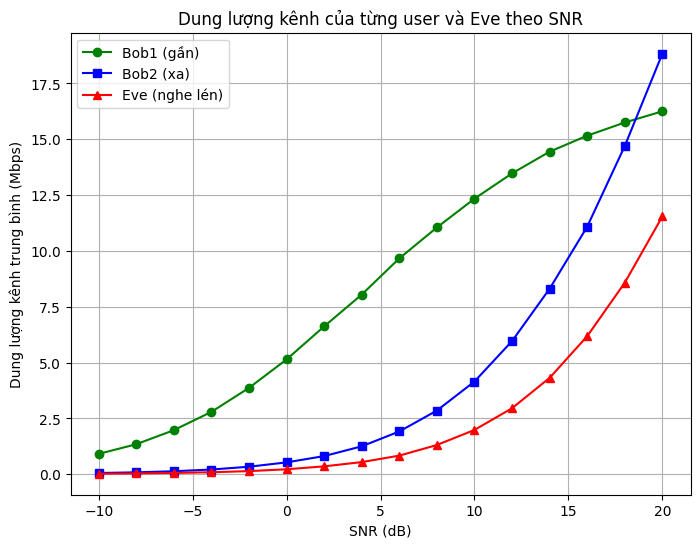

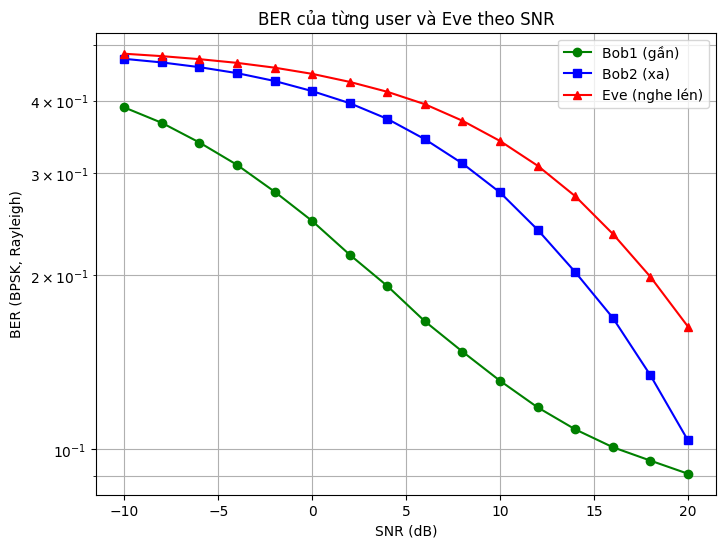

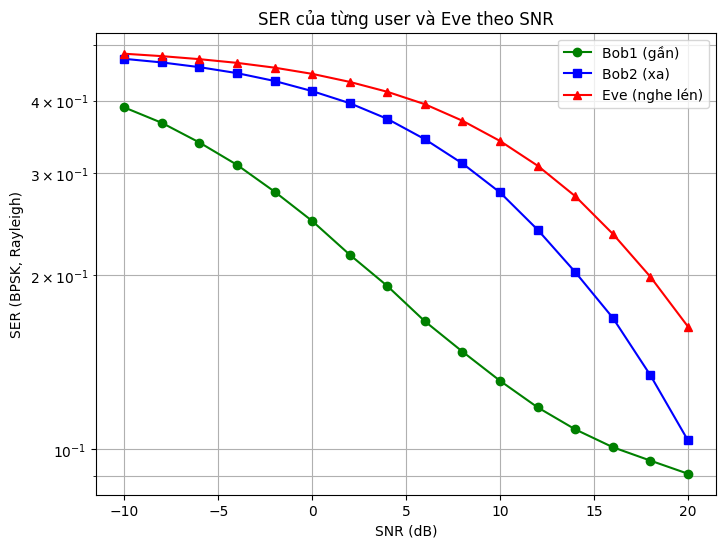

In [ ]:
## Simulation Improvement: Kết hợp hai kịch bản
# Kịch bản 1: 1 user hợp lệ (Bob), 1 Eve, mô phỏng theo khoảng cách d_{AE}
# Kịch bản 2: Multi-user NOMA (Bob1, Bob2, Eve), mô phỏng theo SNR, BER/SER, dung lượng

import numpy as np
import matplotlib.pyplot as plt

# ===================== KỊCH BẢN 1: THEO KHOẢNG CÁCH d_{AE} =====================
print("\n===== KỊCH BẢN 1: 1 user + Eve, mô phỏng theo d_{AE} =====")
# Thông số hệ thống
P_A = 1
N_0 = 10**((-134 - 30) / 10)
alpha = 3
epsilon_S = 0.5
B = 10e6
num_samples = int(1e4)
dE_range = np.linspace(100, 500, 50)
dB = 50  # Bob cố định
O_S = np.zeros(len(dE_range))
R_s = np.zeros(len(dE_range))
eta_s = np.zeros(len(dE_range))

print("==== THÔNG SỐ HỆ THỐNG ====")
print(f"Công suất truyền P_A: {P_A} W")
print(f"Nhiễu nền N_0: {N_0:.2e} W")
print(f"Hệ số suy hao alpha: {alpha}")
print(f"Ngưỡng bảo mật epsilon_S: {epsilon_S:.4f} (bits/s/Hz)")
print(f"Băng thông: {B/1e6:.1f} MHz")
print(f"Khoảng cách d_B: {dB}")
print(f"Khoảng cách d_E: {dE_range[0]:.1f} -> {dE_range[-1]:.1f} m (step {dE_range[1]-dE_range[0]:.1f})")
print("============================\n")

for i in range(len(dE_range)):
    d_E = dE_range[i]
    h_B = np.sqrt(0.5) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    h_E = np.sqrt(0.5) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    SNR_Bob = (P_A * np.abs(h_B)**2) / (dB**alpha * N_0)
    SNR_Eve = (P_A * np.abs(h_E)**2) / (d_E**alpha * N_0)
    C_AB = B * np.log2(1 + SNR_Bob)
    C_AE = B * np.log2(1 + SNR_Eve)
    C_S = np.maximum(0, C_AB - C_AE)
    R_s[i] = np.mean(C_S) / B
    O_S[i] = np.mean(C_S < epsilon_S * B)
    eta_s[i] = R_s[i]
    print(f"d_E = {d_E:.1f} m | O_S = {O_S[i]:.4f} | R_s = {R_s[i]:.4f} | eta_s = {eta_s[i]:.4f}")

# Biểu đồ xác suất dừng
plt.figure(figsize=(8,6))
plt.plot(dE_range, O_S, 'b-o', label='Secrecy Outage Probability')
plt.xlabel('Khoảng cách từ A đến E (d_{AE}) (m)')
plt.ylabel('Xác suất dừng bảo mật O_S')
plt.title('Biểu diễn xác suất dừng theo khoảng cách d_{AE}')
plt.grid(True)
plt.legend()
plt.show()

# Biểu đồ Secrecy Rate
printf = plt.figure(figsize=(8,6))
plt.plot(dE_range, R_s, 'g-s', label='Secrecy Rate')
plt.xlabel('Khoảng cách từ A đến E (d_{AE}) (m)')
plt.ylabel('Secrecy Rate (bits/s/Hz)')
plt.title('Secrecy Rate theo khoảng cách d_{AE}')
plt.grid(True)
plt.legend()
plt.show()

# Biểu đồ Secrecy Spectral Efficiency
plt.figure(figsize=(8,6))
plt.plot(dE_range, eta_s, 'r-^', label='Secrecy Spectral Efficiency')
plt.xlabel('Khoảng cách từ A đến E (d_{AE}) (m)')
plt.ylabel('Secrecy Spectral Efficiency (bits/s/Hz)')
plt.title('Secrecy Spectral Efficiency theo khoảng cách d_{AE}')
plt.grid(True)
plt.legend()
plt.show()

# ===================== KỊCH BẢN 2: MULTI-USER, THEO SNR =====================
print("\n===== KỊCH BẢN 2: Multi-user NOMA, mô phỏng theo SNR =====")
# Thông số hệ thống
SNR_dB_range = np.arange(-10, 21, 2)
alpha1 = 0.7
alpha2 = 0.3
d_B1 = 50
d_B2 = 100
d_E = 200
C_B1 = np.zeros(len(SNR_dB_range))
C_B2 = np.zeros(len(SNR_dB_range))
C_E = np.zeros(len(SNR_dB_range))
BER_B1 = np.zeros(len(SNR_dB_range))
BER_B2 = np.zeros(len(SNR_dB_range))
BER_E = np.zeros(len(SNR_dB_range))
SER_B1 = np.zeros(len(SNR_dB_range))
SER_B2 = np.zeros(len(SNR_dB_range))
SER_E = np.zeros(len(SNR_dB_range))

print(f"Phân bổ công suất: alpha1 = {alpha1}, alpha2 = {alpha2} (tổng = {alpha1+alpha2})")
print(f"Khoảng cách: Bob1 = {d_B1}m, Bob2 = {d_B2}m, Eve = {d_E}m")

for idx, SNR_dB in enumerate(SNR_dB_range):
    SNR_linear = 10**(SNR_dB/10)
    P_A_eff = SNR_linear * d_B1**alpha * N_0
    h_B1 = np.sqrt(0.5) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    h_B2 = np.sqrt(0.5) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    h_E = np.sqrt(0.5) * (np.random.randn(num_samples) + 1j * np.random.randn(num_samples))
    SNR_B2 = (P_A_eff * alpha2 * np.abs(h_B2)**2) / (d_B2**alpha * N_0)
    SNR_B1 = (P_A_eff * alpha1 * np.abs(h_B1)**2) / (d_B1**alpha * N_0 + P_A_eff * alpha2 * np.abs(h_B1)**2)
    SNR_E = (P_A_eff * np.abs(h_E)**2) / (d_E**alpha * N_0)
    C_B1[idx] = np.mean(B * np.log2(1 + SNR_B1))
    C_B2[idx] = np.mean(B * np.log2(1 + SNR_B2))
    C_E[idx] = np.mean(B * np.log2(1 + SNR_E))
    BER_B1[idx] = np.mean(0.5 * (1 - np.sqrt(SNR_B1 / (1 + SNR_B1))))
    BER_B2[idx] = np.mean(0.5 * (1 - np.sqrt(SNR_B2 / (1 + SNR_B2))))
    BER_E[idx] = np.mean(0.5 * (1 - np.sqrt(SNR_E / (1 + SNR_E))))
    SER_B1[idx] = BER_B1[idx]
    SER_B2[idx] = BER_B2[idx]
    SER_E[idx] = BER_E[idx]
    print(f"SNR = {SNR_dB} dB | C_B1 = {C_B1[idx]/1e6:.2f} Mbps | C_B2 = {C_B2[idx]/1e6:.2f} Mbps | C_E = {C_E[idx]/1e6:.2f} Mbps | BER_B1 = {BER_B1[idx]:.4e} | BER_B2 = {BER_B2[idx]:.4e} | BER_E = {BER_E[idx]:.4e}")

# Vẽ biểu đồ dung lượng kênh
plt.figure(figsize=(8,6))
plt.plot(SNR_dB_range, C_B1/1e6, 'g-o', label='Bob1 (gần)')
plt.plot(SNR_dB_range, C_B2/1e6, 'b-s', label='Bob2 (xa)')
plt.plot(SNR_dB_range, C_E/1e6, 'r-^', label='Eve (nghe lén)')
plt.xlabel('SNR (dB)')
plt.ylabel('Dung lượng kênh trung bình (Mbps)')
plt.title('Dung lượng kênh của từng user và Eve theo SNR')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ biểu đồ BER
plt.figure(figsize=(8,6))
plt.semilogy(SNR_dB_range, BER_B1, 'g-o', label='Bob1 (gần)')
plt.semilogy(SNR_dB_range, BER_B2, 'b-s', label='Bob2 (xa)')
plt.semilogy(SNR_dB_range, BER_E, 'r-^', label='Eve (nghe lén)')
plt.xlabel('SNR (dB)')
plt.ylabel('BER (BPSK, Rayleigh)')
plt.title('BER của từng user và Eve theo SNR')
plt.legend()
plt.grid(True, which='both')
plt.show()

# Vẽ biểu đồ SER (ở đây SER = BER do BPSK)
plt.figure(figsize=(8,6))
plt.semilogy(SNR_dB_range, SER_B1, 'g-o', label='Bob1 (gần)')
plt.semilogy(SNR_dB_range, SER_B2, 'b-s', label='Bob2 (xa)')
plt.semilogy(SNR_dB_range, SER_E, 'r-^', label='Eve (nghe lén)')
plt.xlabel('SNR (dB)')
plt.ylabel('SER (BPSK, Rayleigh)')
plt.title('SER của từng user và Eve theo SNR')
plt.legend()
plt.grid(True, which='both')
plt.show()